In [ ]:
import sys
sys.path.insert(0, "..")

import json
from pathlib import Path

%load_ext autoreload
%autoreload 2

ROOT = Path().cwd().parent
ROOT

PosixPath('/Users/I550854/Documents/Master Thesis/gdpa-benchmark')

In [6]:
path = ROOT / "results/mas_eval/20260423_082834_mistral-large_N3_T5_temp1.0_q56_R25.json"
data = json.loads(path.read_text())

metrics = data["metrics"]
R = data["R"]
N = data["N"]
T = data["T"]
ground_truth = data["ground_truth"]

print(f"R={R}, N={N}, T={T}")

R=25, N=3, T=5


In [ ]:
import numpy as np
from collections import Counter

reps_raw = data["repetitions"]
reps_met = metrics["repetitions"]

n_correct = sum(r["correct"] for r in reps_raw)
print(f"Majority-vote accuracy: {n_correct}/{R} = {n_correct/R:.0%}")

r0_acc = np.mean([np.array(rm["per_agent_per_round"]["correct"], dtype=float)[:, 0].mean() for rm in reps_met])
rT_acc = np.mean([np.array(rm["per_agent_per_round"]["correct"], dtype=float)[:, T].mean() for rm in reps_met])
print(f"Single-agent accuracy r=0: {r0_acc:.0%}")
print(f"Single-agent accuracy r={T}: {rT_acc:.0%}")

majority_wins, majority_unanimous = [], []
for r in reps_raw:
    r0_beliefs = [e["belief"] for e in r["trajectory"][0]["phase_b"]]
    rT_beliefs = [e["belief"] for e in r["trajectory"][-1]["phase_b"]]
    top_two = Counter(r0_beliefs).most_common(2)
    if len(top_two) < 2 or top_two[0][1] > top_two[1][1]:
        r0_majority = top_two[0][0]
        rT_counts = Counter(rT_beliefs)
        majority_wins.append(rT_counts.most_common(1)[0][0] == r0_majority)
        majority_unanimous.append(all(b == r0_majority for b in rT_beliefs))

n = len(majority_wins)
print(f"\nReps with r=0 majority: {n}/{R}")
print(f"r=0 majority → final majority: {sum(majority_wins)}/{n} = {np.mean(majority_wins):.0%}")
print(f"r=0 majority → final unanimous: {sum(majority_unanimous)}/{n} = {np.mean(majority_unanimous):.0%}")

all_flip, maj_flip, min_flip = [], [], []
for r in reps_raw:
    n_rounds = len(r["trajectory"])
    r0_beliefs = [e["belief"] for e in r["trajectory"][0]["phase_b"]]
    top = Counter(r0_beliefs).most_common()
    has_majority = len(top) >= 2 and top[0][1] > top[1][1]
    maj_belief = top[0][0]
    for i in range(N):
        b0 = r["trajectory"][0]["phase_b"][i]["belief"]
        flipped = any(r["trajectory"][rnd]["phase_b"][i]["belief"] != b0 for rnd in range(1, n_rounds))
        all_flip.append(flipped)
        if has_majority:
            (maj_flip if b0 == maj_belief else min_flip).append(flipped)

print(f"\nAgent flip rate (ever): {sum(all_flip)}/{len(all_flip)} = {np.mean(all_flip):.0%}")
if min_flip:
    print(f"  r=0 minority agents: {sum(min_flip)}/{len(min_flip)} = {np.mean(min_flip):.0%}")
if maj_flip:
    print(f"  r=0 majority agents: {sum(maj_flip)}/{len(maj_flip)} = {np.mean(maj_flip):.0%}")

### Visualization
This section visualizes the results to gain a better understanding of the inner working of the MAS.

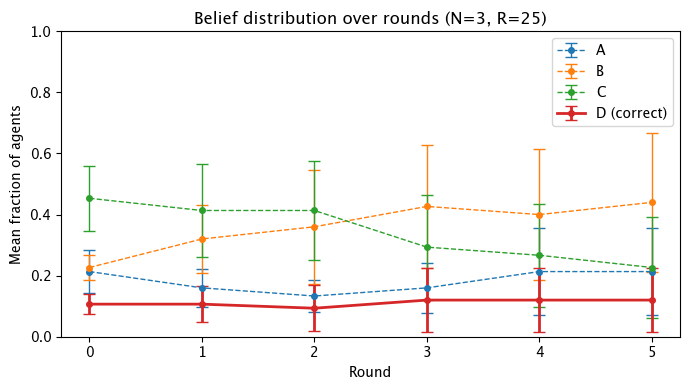

We don't see convergence towards the correct answer over rounds. The agents are not capable of finding better results, even in a MAS setup.


In [ ]:
import matplotlib.pyplot as plt

# shape: [R, T+1, 4] — fraction of agents per option per round per rep
T1 = T + 1
options = list("ABCD")
fracs = np.zeros((R, T1, 4))

for ri_rep, r_raw in enumerate(reps_raw):
    for ri_round, entry in enumerate(r_raw["trajectory"]):
        beliefs = [e["belief"] for e in entry["phase_b"]]
        for oi, opt in enumerate(options):
            fracs[ri_rep, ri_round, oi] = beliefs.count(opt) / N

mean_fracs = fracs.mean(axis=0)  # [T+1, 4]
std_fracs  = fracs.var(axis=0)   # [T+1, 4]
rounds = list(range(T1))

fig, ax = plt.subplots(figsize=(7, 4))
for oi, opt in enumerate(options):
    lw = 2 if opt == ground_truth else 1
    ls = "-" if opt == ground_truth else "--"
    label = f"{opt} (correct)" if opt == ground_truth else opt
    ax.errorbar(
        rounds, mean_fracs[:, oi], yerr=std_fracs[:, oi],
        label=label, linewidth=lw, linestyle=ls,
        marker="o", markersize=4, capsize=4,
    )

ax.set_xlabel("Round")
ax.set_ylabel("Mean fraction of agents")
ax.set_xticks(rounds)
ax.set_ylim(0, 1)
ax.legend()
ax.set_title(f"Belief distribution over rounds (N={N}, R={R})")
plt.tight_layout()
plt.show()

print("We don't see convergence towards the correct answer over rounds. The agents are not capable of finding better results, even in a MAS setup.")

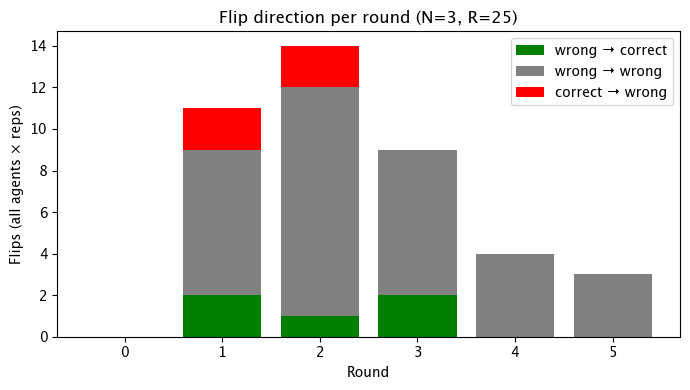

Interesting that most flips don't happen in the first round, but in the second round. The decay afterwards is understandable because of convergence.
Also the flips appear to be mostly random in direction, need to explore majority dynamics of that.


In [15]:
toward_correct = np.zeros(T1)
away_correct   = np.zeros(T1)
neutral_flip   = np.zeros(T1)

for r_raw, rm in zip(reps_raw, reps_met):
    beliefs_by_round = {
        e["round"]: {pb["id"]: pb["belief"] for pb in e["phase_b"]}
        for e in r_raw["trajectory"]
    }
    f = np.array(rm["per_agent_per_round"]["flip"], dtype=object)
    f = np.where(f == None, 0, f).astype(float)

    for ri_round, entry in enumerate(r_raw["trajectory"]):
        if ri_round == 0:
            continue
        r_cur  = rounds[ri_round]
        r_prev = rounds[ri_round - 1]
        for i in range(N):
            if f[i, ri_round] != 1:
                continue
            prev = beliefs_by_round[r_prev][i]
            cur  = beliefs_by_round[r_cur][i]
            if cur == ground_truth:
                toward_correct[ri_round] += 1
            elif prev == ground_truth:
                away_correct[ri_round] += 1
            else:
                neutral_flip[ri_round] += 1

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(rounds, toward_correct, label="wrong → correct", color="green")
ax.bar(rounds, neutral_flip,   label="wrong → wrong",   color="gray",  bottom=toward_correct)
ax.bar(rounds, away_correct,   label="correct → wrong", color="red",   bottom=toward_correct + neutral_flip)
ax.set_xlabel("Round")
ax.set_ylabel("Flips (all agents × reps)")
ax.set_xticks(rounds)
ax.legend()
ax.set_title(f"Flip direction per round (N={N}, R={R})")
plt.tight_layout()
plt.show()


print("Interesting that most flips don't happen in the first round, but in the second round. The decay afterwards is understandable because of convergence.")
print("Also the flips appear to be mostly random in direction, need to explore majority dynamics of that.")

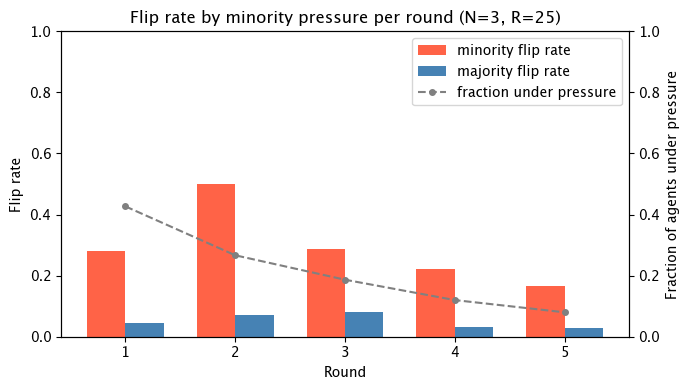

minority=your belief is not the modal belief at that round, majority=your belief is the modal belief at that round
Confirms that we have a majority dynamics where agents in the minority are more likely to flip than those in the majority, especially in early rounds.


In [18]:
from collections import defaultdict

minority_flips  = np.zeros(T1)
minority_total  = np.zeros(T1)
majority_flips  = np.zeros(T1)
majority_total  = np.zeros(T1)

for r_raw, rm in zip(reps_raw, reps_met):
    beliefs_by_round = {
        e["round"]: {pb["id"]: pb["belief"] for pb in e["phase_b"]}
        for e in r_raw["trajectory"]
    }
    f = np.array(rm["per_agent_per_round"]["flip"], dtype=object)
    f = np.where(f == None, 0, f).astype(float)

    for ri_round in range(1, T1):
        r_cur  = rounds[ri_round]
        r_prev = rounds[ri_round - 1]
        prev_beliefs = beliefs_by_round[r_prev]

        for i in range(N):
            b_i = prev_beliefs[i]
            n_disagree = sum(1 for j in range(N) if j != i and prev_beliefs[j] != b_i)
            under_pressure = n_disagree > (N - 1) / 2
            flipped = f[i, ri_round]

            if under_pressure:
                minority_total[ri_round] += 1
                minority_flips[ri_round] += flipped
            else:
                majority_total[ri_round] += 1
                majority_flips[ri_round] += flipped

minority_rate  = np.divide(minority_flips,  minority_total,  where=minority_total  > 0, out=np.full(T1, np.nan))
majority_rate  = np.divide(majority_flips,  majority_total,  where=majority_total  > 0, out=np.full(T1, np.nan))
pressure_frac  = minority_total / (N * R)

x = np.array(rounds[1:])
w = 0.35

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.bar(x - w/2, minority_rate[1:], w, label="minority flip rate", color="tomato")
ax1.bar(x + w/2, majority_rate[1:], w, label="majority flip rate", color="steelblue")
ax1.set_xlabel("Round")
ax1.set_ylabel("Flip rate")
ax1.set_xticks(x)
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(x, pressure_frac[1:], color="gray", linestyle="--", marker="o", markersize=4, label="fraction under pressure")
ax2.set_ylabel("Fraction of agents under pressure")
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
ax1.set_title(f"Flip rate by minority pressure per round (N={N}, R={R})")
plt.tight_layout()
plt.show()

print("minority=your belief is not the modal belief at that round, majority=your belief is the modal belief at that round")
print("Confirms that we have a majority dynamics where agents in the minority are more likely to flip than those in the majority, especially in early rounds.")